In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

In [40]:
surf = pd.read_csv(r'C:\Damir\unsupervised_seism_segment_novatek\facies_marks\reflecting_horizon.csv')

In [ ]:
from surface_extractor import SeismicMapExtractor

In [61]:
extractor = SeismicMapExtractor(
    
        max_distance=50.0,  # you can pass any if load precalculated indices
        use_dask=True,
        chunks=None
    )

In [ ]:
# some cube
cube_down = xr.load_dataset(r'C:\Damir\unsupervised_seism_segment_novatek\cubes_as_xarrays\horizon_cubes\down_cube4_times_xy\cubes_xr\Cube_2019_SUMM_horzn_down.nc')
# in case you have numpy array and any xarray of the same shape, you can convert numpy to xarray:
# any_xarray['data'] = (any_xarray.dims, numpy_array)

In [62]:
extractor.build_index_map(cube_down, surf) #time-consuming step, you can avoid it if you have precalculated indices

BUILDING SPATIAL INDEX MAP
Cube dimensions: iline=741, xline=707, twt=239
Number of surface points: 12363960
Building KD-tree...
Querying KD-tree for nearest neighbors...

INDEX MAP BUILD COMPLETE
Valid points within 100.0m: 8404367 / 12363960 (68.0%)
Mean distance: 2651.12m
Max distance: 21926.22m
Std distance: 4615.51m

Distance percentiles:
  10th: 20.38m
  25th: 35.06m
  50th: 46.50m
  75th: 3764.47m
  90th: 11165.02m
  95th: 13518.01m


In [63]:
# extractor.save_index_map('surface_indices_down.npz') # if you call build_index_map you can save it 
    
extractor.load_index_map('surface_indices_down.npz') # load precalculated indecis from yandex disk

Index map saved to surface_indices_down.npz
Index map loaded from surface_indices_down.npz
Valid points: 8404367 / 12363960 (68.0%)


In [64]:
extractor.set_surface_from_df(surf) # set surface (reflecting.horizon.csv) from yandex disk
#read_surface_points(surf_path) #also you can read it

In [66]:
#extract data from cube on the surface

results, X, Y, Z = extractor.extract_and_create_map(
                          cube=cube_down,
                          data_var='data',
                          output_nc_file= None)


Extracting data from cube...
Creating 2D map on original CDP grid...

Map Statistics:
  Original CDP grid shape: (741, 707)
  Total CDP points in cube: 523887
  Surface points intersecting cube: 523887 (100.00%)
  Data range: [-30911.79, 40524.25]
  Data mean ± std: 5605.19 ± 7334.32


(<Figure size 1400x1000 with 2 Axes>,
 <Axes: title={'center': 'Seismic Amplitude Map\nSurface points: 523887 / 523887 (100.0% of CDP grid) | Range: [-30911.79, 40524.25]'}, xlabel='CDP X (m)', ylabel='CDP Y (m)'>)

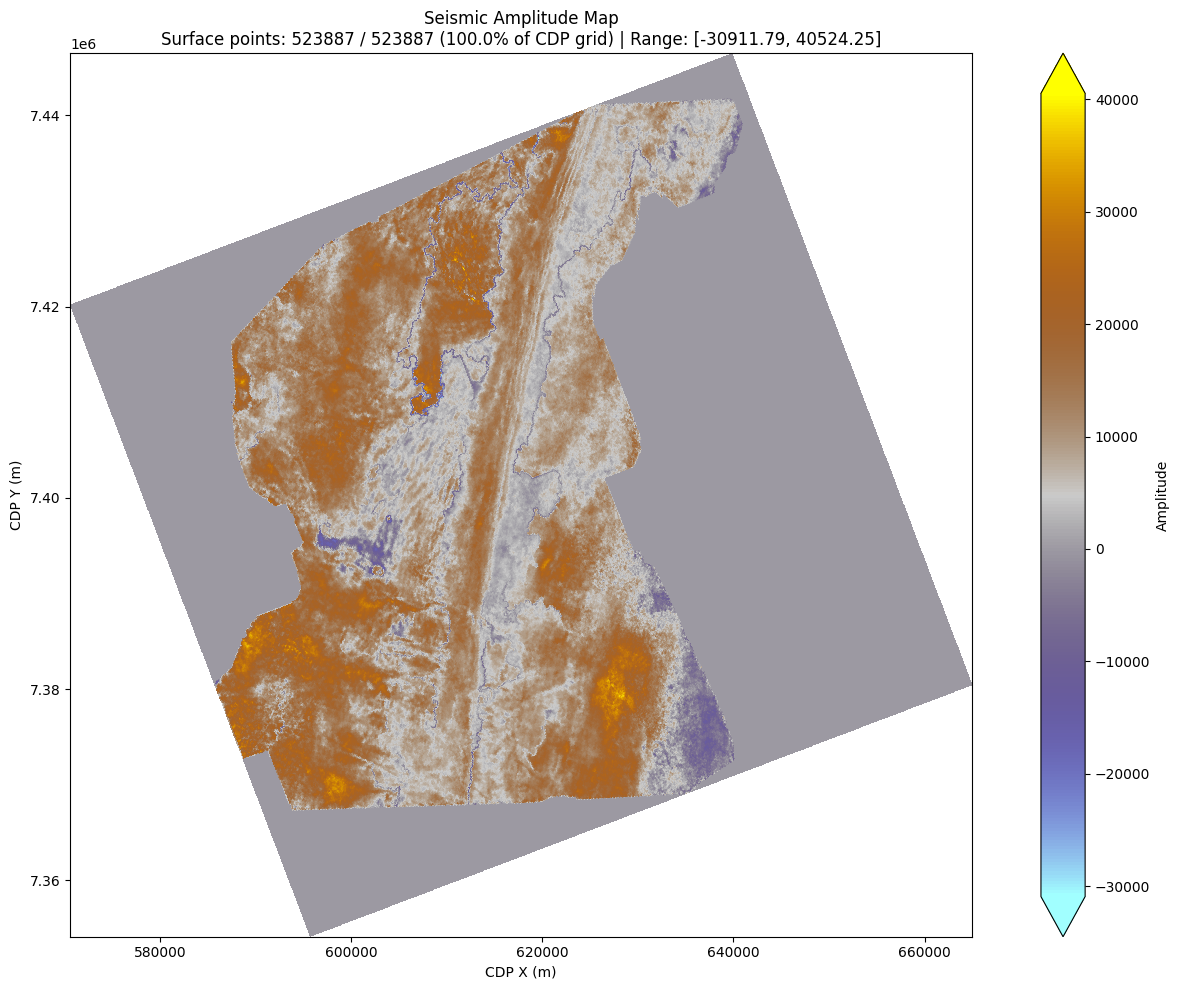

In [68]:
#function to plot continuous variable
extractor.plot_map_as_image(
    X, Y, Z,
    title="Seismic Amplitude Map",
    cmap=odt_petrel,
    save_path=None
)

In [ ]:
#function to plot discrete variable, -1 are treated as nans
extractor.plot_cluster_map_as_image(
    X, Y, Z,
    title="Cluster Map",
    save_path=None)

In [ ]:
facies_map = np.load('facies_map_path.npy') # Z ann facies_map have the same shape, so you can calculate element-wise metrics